In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from openpyxl import Workbook
from datetime import datetime
import json

Welcome to JupyROOT 6.30/04


In [2]:
root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")

root.gStyle.SetPaintTextFormat("1.1f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/


V_current_level = 230.  # Leakage current measured at this V
V_current_monitor = 200. #Voltage up to which the current level is monitored
VBD_expected = 200.  # 230   minimum VBD to be considered for GOOD or MEDIUM categories, if VBD<VBD_expected sensor is BAD
V_min_kfactor = 100.  #k-factor not used to calculate VBD if VBD<V_min_kfactor
I_thr = 10. #sensor discarded if I > I_thr [uA] in the voltage operation range [ 0-V_current_monitor ]
I_compliance = 1000 # VBD calculation begins when I < I_compliance  [uA]
I_compliance_minimum = 50 # [uA] VBD calculation performed only if compliance was set above this threshold
k_thr = 8. # 20  k value to define VBD using k-factor method
current_conversion_value = 1E6 # conversion from [A] (raw data) to [uA] (used in the final plots)
start_bd_calculation = 5 #BD calculation start from this sampled bias point: avoid considering the very first voltages of the bias sweep 
low_iv_range = 0.1  #low and high ranges for I@100V plot [uA]
high_iv_range = 500
low_vbd_range = 0 #low and high ranges for VBD plot [V]
high_vbd_range = 300
start_wafer = 1 #first wafer number in the dataset
start_row = 3 #the first row of the wafer to be measured
start_col = 2 #the first column of the wafer to be measured 
bcurrent = False
bvoltage = False
bcategory = True
bnoisy = False
save = False
verbose = False
write_xl_for_db = True  #produces an xls file with the right format to be uploaded in the ETL database.

if(bcategory): 
    root.gStyle.SetPalette(3,palette) # custom palette used for Categories

if(bvoltage):
    #root.gStyle.SetPalette("Black Body") # palette for VBD
    root.gStyle.SetPalette(70) # palette for VBD

if(bcurrent or bnoisy):
    #root.gStyle.SetPalette("Black Body") # palette for I@V_current_level
    root.gStyle.SetPalette(70)
    root.TColor.InvertPalette()

invert_polarity=True

file_qa = root.TFile.Open("../../root_files/UFSD4_16x16_IVtree.root")
tree_qa = file_qa.Get("Tree")
  
  
if(write_xl_for_db):
    wb = Workbook()
    ws = wb.active
    ws["A1"] = "Serial Number"
    ws["B1"] = "Component Type" 
    ws["C1"] = "Vendor" 
    ws["D1"] = "Production" 
    ws["E1"] = "Wafer" 
    ws["F1"] = "Geometry"
    ws["G1"] = "Row" 
    ws["H1"] = "Column"
    ws["I1"] = "Vendor Leakage Current [uA]"
    ws["J1"] = "Vendor Breakdown Voltage [V]" 
    ws["K1"] = "Vendor Category"
    ws["L1"] = "Gain Category"
    ws["M1"] = "Comments"
    print("Xls File for database has been created")
  
  
counter_qa = 0
I_qa_100V = 0.
VBD_qa_u = 0.
VBD_qa_d = 0.
k_qa_u = []
k_qa_d = []
k_qa_u.append(0.)
k_qa_u.append(0.)
k_qa_d.append(0.)
k_qa_d.append(0.)

tests_json = []

current_levels_counter=[0,0,0,0,0,0]
vcount_vbd_qa = [[[0 for i in range(5)] for j in range(5)] for k in range(18)]
vcount_i_qa = [[[0 for i in range(5)] for j in range(5)] for k in range(18)]
vcount_bump_qa = [[[0 for i in range(5)] for j in range(5)] for k in range(18)]
vvbd_qa = [[[0 for i in range(5)] for j in range(5)] for k in range(18)]
vi_qa = [[[0 for i in range(5)] for j in range(5)] for k in range(18)]
vbump_qa = [[[0 for i in range(5)] for j in range(5)] for k in range(18)]
#vnoisy_qa = None
hI_qa_100V = []
hV_qa = []
hbump_qa = []
hnoisy_qa = []
hcount_qa = []
min_I = []

for i in range(18):
    hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level)+"V_W"+str(i+1), "I@"+str(V_current_level)+"V on-wafer W"+str(i+1), 5,2,7,5,2,7 ) )
    hV_qa.append( TH2F( "V_qa_W"+str(i+1), "VBD on-wafer W"+str(i+1), 5,2,7,5,2,7 ) )
    min_I.append(1000)

    hbump_qa.append( TH2F( "bump_qa_W"+str(i+1), "Categories on-wafer W"+str(i+1), 5,2,7,5,2,7) )
    hnoisy_qa.append( TH2F( "noisy_qa_W"+str(i+1), "Bad pads on-wafer W"+str(i+1), 5,2,7,5,2,7) )

dumb_counter= 0. # Total number of sensors/measurements in the root file
non_empty_counter= 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter= 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
total_sensors_counter_qa= 0. #Fraction of sensors whose category can be properly defined
good_sensors_counter_qa= 0. #Fraction of GOOD sensors
bad_sensors_counter_qa= 0. #Fraction of BAD sensors
medium_sensors_counter_qa= 0. #Fraction of MEDIUM sensors
iv_quality = bool() # Boolean reflecting the quality of the IV curve: sensor is BAD whenever iv_quality is set to False

save_path = '/Users/icosivi/Desktop/plot/'

Xls File for database has been created


In [3]:
for event in tree_qa:
    dumb_counter+=1
    if(int(event.IBACK.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.IBACK.at(event.IBACK.size()-1)<0 ): 
        Iback = [float(-i) for i in event.IBACK]        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [i for i in event.IBACK]

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]


      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        VBD_qa_u = -1000.
        VBD_qa_d = -1000.
        
        type_counter = 0
        type_counter_I_qa = 0
        type_counter_V_qa_u = 0
        type_counter_V_qa_d = 0
      
      
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level and Vbias[i]==V_current_level ):
            if( Vbias[i]==V_current_level ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=V_current_monitor and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
        if( I_qa_100V<0. ): 
          iv_quality=False
          
        ### VBD calculation ###
        if( Iback[ -1 ]>I_compliance_minimum*(1./current_conversion_value) ):
          ### VBD "up" (Calculation start from the end of the Voltage array downwards) ###
          for i in reversed(range(start_bd_calculation,int(len(Iback))-1)):
            if(Vbias[len(Iback)-1]<V_min_kfactor): 
                VBD_qa_u = Vbias[len(Iback)-1]
                break 
            
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):
              k_qa_u[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_u[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i]) 
              #if(event.wafer==1 and event.row==4 and event.column==3 ): 
                 #print(str(k_qa_u[0])+' '+str(k_qa_u[1])+' '+str(Vbias[i]))
      
              if( k_qa_u[0]<k_thr and k_qa_u[1]>=k_thr ):
                VBD_qa_u = Vbias[i] 
                break 
              
         
          ### VBD "down" (Calculation start from the beginning of the Voltage array upwards) ###
          for i in range(start_bd_calculation,int(len(Iback))-1):
            if(Vbias[len(Iback)-1]<V_min_kfactor):
                VBD_qa_d = Vbias[len(Iback)-1] 
                break 
      
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):    
              k_qa_d[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_d[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i])
      
              if( k_qa_d[0]<k_thr and k_qa_d[1]>=k_thr ):
                VBD_qa_d = Vbias[i] 
                break
      
        if(VBD_qa_u!=-1000 and VBD_qa_d!=-1000): 
          vvbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VBD_qa_u
          vcount_vbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
      
        if( VBD_qa_u>VBD_expected and VBD_qa_d!=-1000 and VBD_qa_d<=VBD_expected ):
          if(verbose): 
            print("!!! SENSOR WITH CURRENT JUMPS ALERT  !!!: from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column))
          #vnoisy_qa[event.wafer-1][event.column-2][event.row-2] += 1
          
          
        if( iv_quality and VBD_qa_u>VBD_expected and VBD_qa_d!=-1000 ):
          if( VBD_qa_d>VBD_expected ):
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
          else:
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 2
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        elif( np.logical_not(iv_quality) or (VBD_qa_d!=-1000 and VBD_qa_u!=-1000 and VBD_qa_u<=VBD_expected ) ):
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        elif(verbose): 
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Current within acceptance, but VBD could not be calculated. PLEASE CHECK.")
      elif(verbose): 
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    elif(verbose):
      print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [4]:
serial_num_counter=0

for i in range(18):
    for j in range(4):
        for k in range(3):
          #if( i!=9 and i!=10 ):
          if( i<20 ):
             serial_num_counter += 1
             serial_num = str(int(serial_num_counter)).zfill(3)
             if(vcount_vbd_qa[i][j][k]!=0): 
               hV_qa[i].Fill( j+start_col, k+start_row, vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               #if(i==0 and j==1 and k==1): 
                 #print(str(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k]))
                 #print(str(vcount_vbd_qa[i][j][k]))
             if(vcount_i_qa[i][j][k]!=0): 
               hI_qa_100V[i].Fill( j+start_col, k+start_row, vi_qa[i][j][k]/vcount_i_qa[i][j][k] )
             
             #if(vnoisy_qa[i][j][k]!=0) hnoisy_qa[i]->Fill(j+2,k+2,1);
             #else hnoisy_qa[i]->Fill(j+2,k+2,0);
  
             if(vcount_bump_qa[i][j][k]==0): 
               hnoisy_qa[i].Fill(j+2,k+2,-1000)
              
               ws["A%i" %(serial_num_counter+1)] = "TYL4U"+serial_num
               ws["B%i" %(serial_num_counter+1)] = "Prototype LGAD"
               ws["C%i" %(serial_num_counter+1)] = "FBK"
               ws["D%i" %(serial_num_counter+1)] = "UFSD4"
               ws["E%i" %(serial_num_counter+1)] = str(i+1)
               ws["F%i" %(serial_num_counter+1)] = "16x16-T10"
               ws["G%i" %(serial_num_counter+1)] = str(k+3)
               ws["H%i" %(serial_num_counter+1)] = str(j+2)
               ws["I%i" %(serial_num_counter+1)] = "--"
               ws["J%i" %(serial_num_counter+1)] = "--"
               ws["K%i" %(serial_num_counter+1)] = "--"
               ws["L%i" %(serial_num_counter+1)] = "--"
               ws["M%i" %(serial_num_counter+1)] = "Could not be analyzed. Please check the measurement"
               
               pippo = {'component_sn': 'TYL4U'+serial_num,
                        'measurement_date': datetime(2023, 1, 1, 12, 0, 0).isoformat(), #year, month, day, hour, minute, second
                        'user_created': 'fsiviero',
                        'data':{
                         'Vendor Leakage Current [uA]': None,
                         'Vendor Breakdown Voltage [V]': None, 
                         'Vendor Category': None,  
                         'Current': Iback,
                         'Voltage': Vbias
                        },
                        'type': 'Sensor Vendor Test',
                        'location': 'FBK'
                       }
               
               tests_json.append(pippo)
          
             if(vcount_bump_qa[i][j][k]!=0):
               total_sensors_counter_qa+=1
               
               ws["A%i" %(serial_num_counter+1)] = "TYL4U"+serial_num
               ws["B%i" %(serial_num_counter+1)] = "Prototype LGAD"
               ws["C%i" %(serial_num_counter+1)] = "FBK"
               ws["D%i" %(serial_num_counter+1)] = "UFSD4"
               ws["E%i" %(serial_num_counter+1)] = str(i+1)
               ws["F%i" %(serial_num_counter+1)] = "16x16-T10"
               ws["G%i" %(serial_num_counter+1)] = str(k+3)
               ws["H%i" %(serial_num_counter+1)] = str(j+2)
               ws["L%i" %(serial_num_counter+1)] = "A"   
               
               vendor_leakage_json = str()
               vendor_vbd_json = str()
               vendor_category_json = str()
               
               if(vcount_i_qa[i][j][k]!=0): 
                 ws["I%i" %(serial_num_counter+1)] = str(vi_qa[i][j][k]/vcount_i_qa[i][j][k])
                 vendor_leakage_json = float(vi_qa[i][j][k]/vcount_i_qa[i][j][k])
               else:
                 ws["I%i" %(serial_num_counter+1)] = "--"
                 vendor_leakage_json = None
                 
               if(vcount_vbd_qa[i][j][k]!=0):
                 ws["J%i" %(serial_num_counter+1)] = str(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k])
                 vendor_vbd_json = float(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k])
               else:
                 ws["J%i" %(serial_num_counter+1)] = "--"
                 vendor_vbd_json = None
                 
               if( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]==1 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,1)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,0)
                 good_sensors_counter_qa+=1
                 ws["K%i" %(serial_num_counter+1)] = "GOOD"
                 vendor_category_json = "GOOD"
               elif( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]>2 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,3)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,0)
                 bad_sensors_counter_qa+=1
                 ws["K%i" %(serial_num_counter+1)] = "BAD"
                 vendor_category_json = "BAD"
               elif( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]>1 and vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]<=2 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,2)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,1)
                 medium_sensors_counter_qa+=1
                 ws["K%i" %(serial_num_counter+1)] = "MEDIUM"
                 vendor_category_json = "MEDIUM"

               pippo = {'component_sn': 'TYL4U'+serial_num,
                        'measurement_date': datetime(2023, 1, 1, 12, 0, 0).isoformat(), #year, month, day, hour, minute, second
                        'user_created': 'fsiviero',
                        'data':{
                         'Vendor Leakage Current [uA]': vendor_leakage_json,
                         'Vendor Breakdown Voltage [V]': vendor_vbd_json, 
                         'Vendor Category': vendor_category_json,  
                         'Current': Iback,
                         'Voltage': Vbias
                        },
                        'type': 'Sensor Vendor Test',
                        'location': 'FBK'
                       }
               
               tests_json.append(pippo)
             
             if(vcount_i_qa[i][j][k]!=0.):
              if( vi_qa[i][j][k]/vcount_i_qa[i][j][k]<10. and vi_qa[i][j][k]/vcount_i_qa[i][j][k]>=0. ): 
               current_levels_counter[0]+=1
              elif( vi_qa[i][j][k]/vcount_i_qa[i][j][k]>=10. and vi_qa[i][j][k]/vcount_i_qa[i][j][k]<50. ): 
               current_levels_counter[1]+=1
              elif( vi_qa[i][j][k]/vcount_i_qa[i][j][k]>=50. and vi_qa[i][j][k]/vcount_i_qa[i][j][k]<100. ): 
               current_levels_counter[2]+=1
              elif( vi_qa[i][j][k]/vcount_i_qa[i][j][k]>=100. and vi_qa[i][j][k]/vcount_i_qa[i][j][k]<500. ): 
               current_levels_counter[3]+=1
              elif( vi_qa[i][j][k]/vcount_i_qa[i][j][k]>=500. ): 
               current_levels_counter[4]+=1
              elif( vcount_i_qa[i][j][k]==0. and vcount_vbd_qa[i][j][k]!=0. ): 
               current_levels_counter[5]+=1

wb.save(save_path+"UFSD4_16x16_on-wafer_results_ETLdb.xlsx")

with open(save_path+'UFSD4_16x16_vendor_tests_ETLdb.json', 'w') as f:
    json.dump(tests_json, f, indent=4)

if(verbose):
  print("Fraction of GOOD sensors (on-wafer): "+str(good_sensors_counter_qa/total_sensors_counter_qa))
  print("Fraction of MEDIUM sensors (on-wafer): "+str(medium_sensors_counter_qa/total_sensors_counter_qa))
  print("Fraction of BAD sensors (on-wafer): "+str(bad_sensors_counter_qa/total_sensors_counter_qa))
  print("Fraction of non-empty IVs: "+str(non_empty_counter/dumb_counter))
  print("Fraction of IVs with non-zero values: "+str(non_zero_counter/dumb_counter))

        

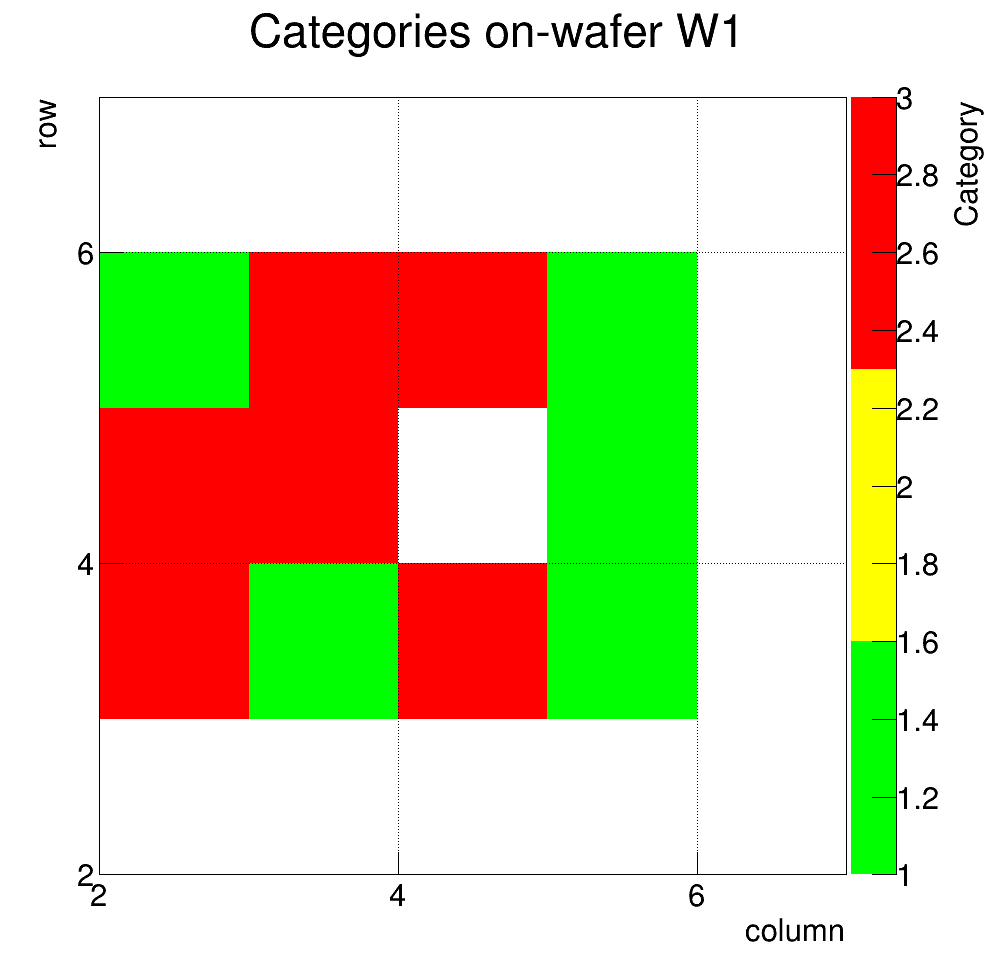

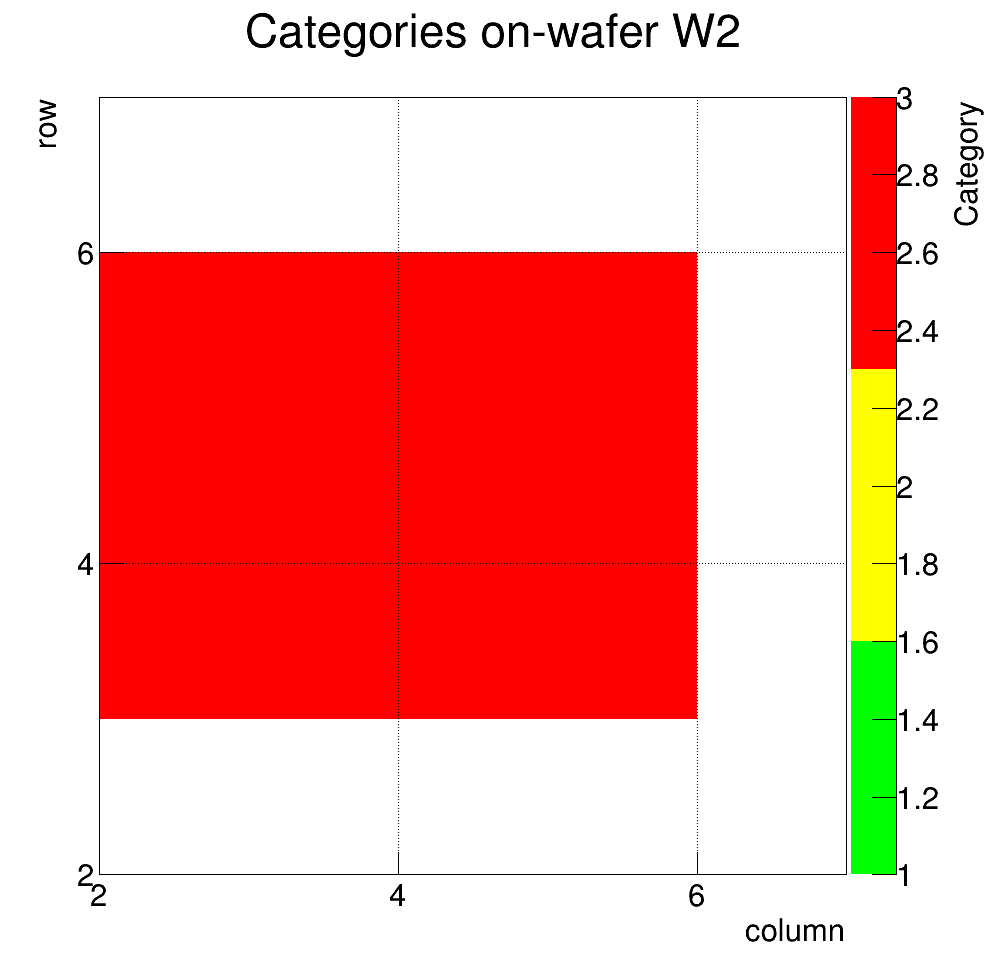

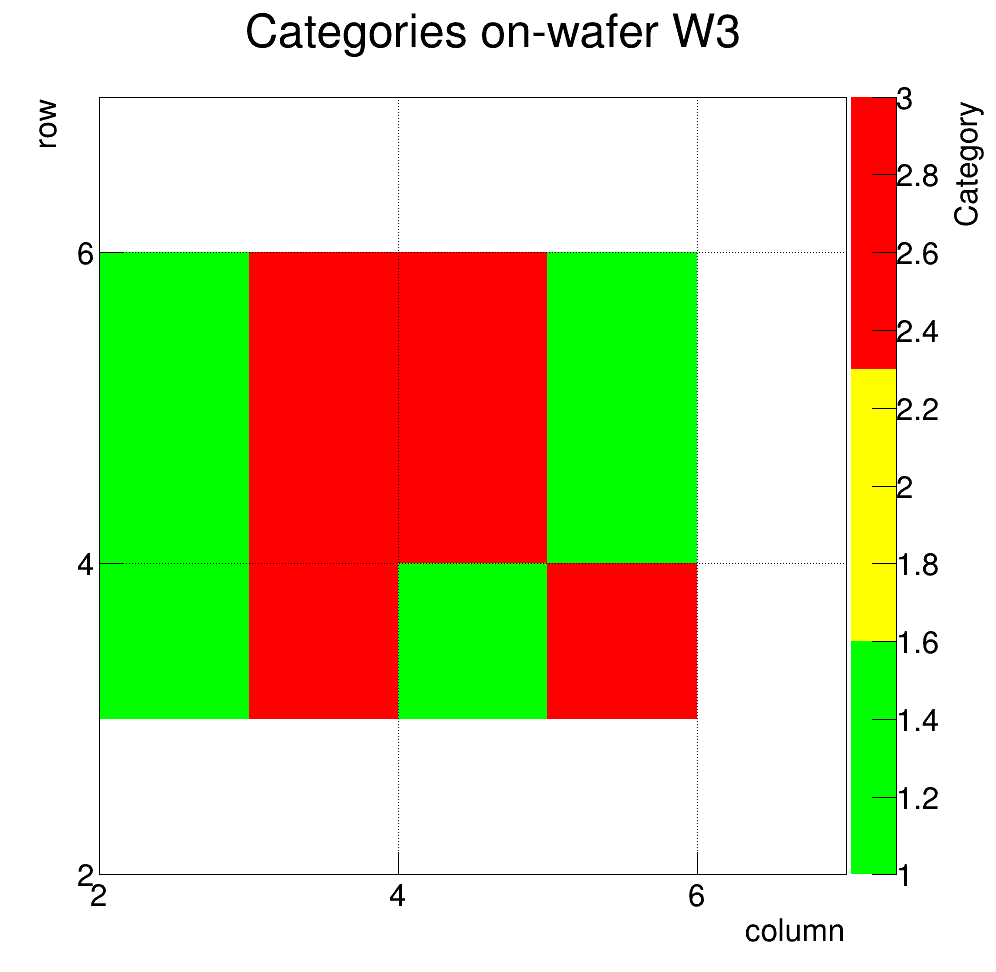

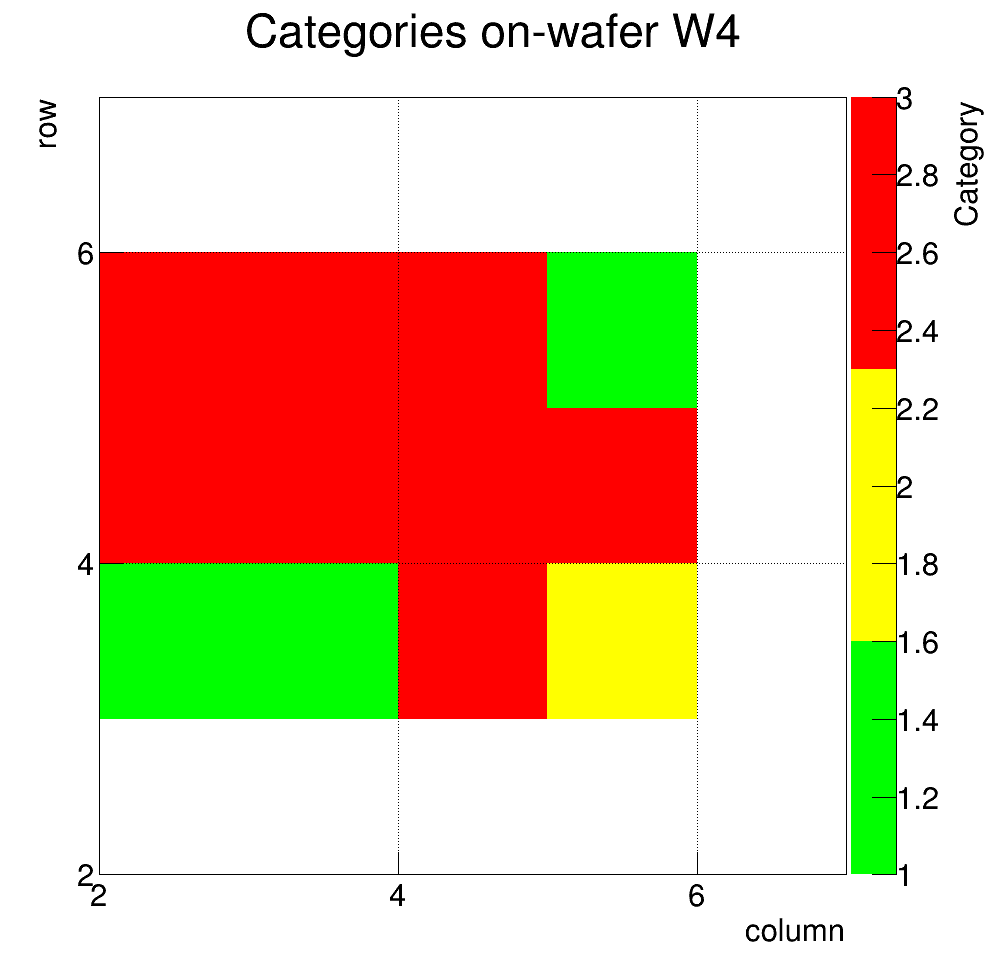

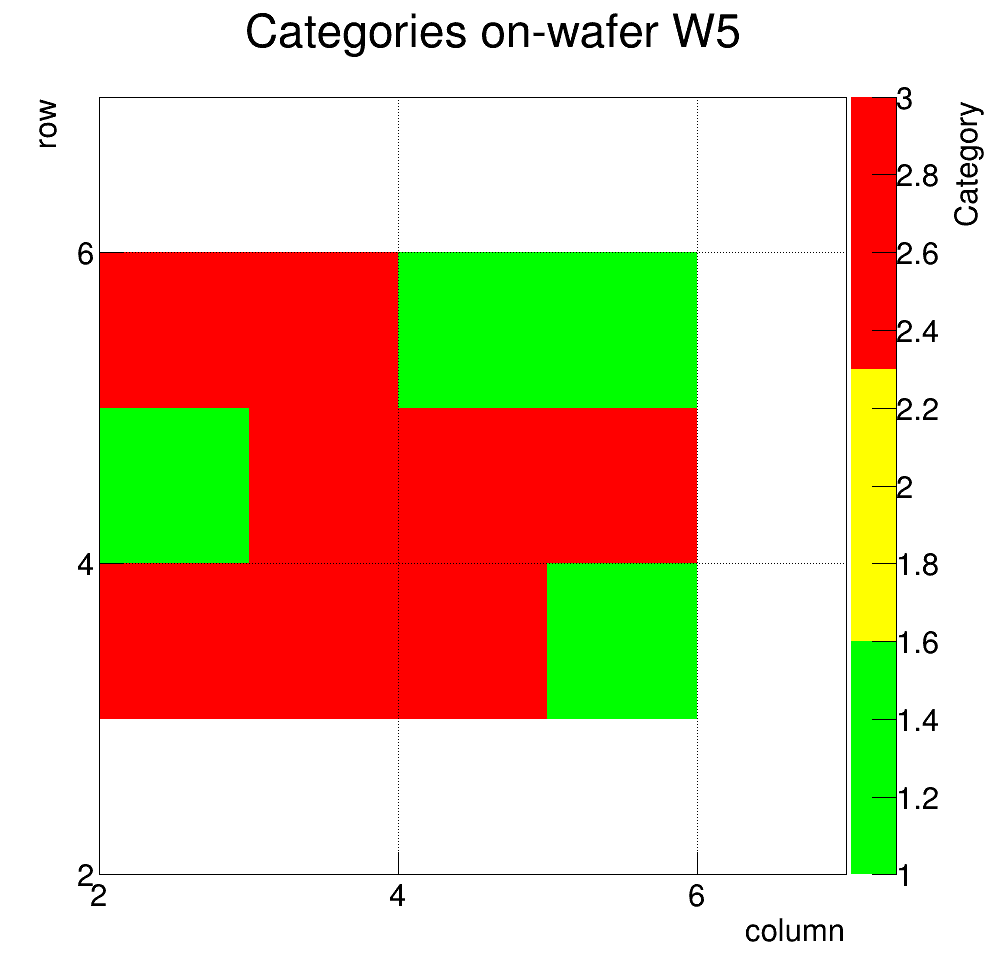

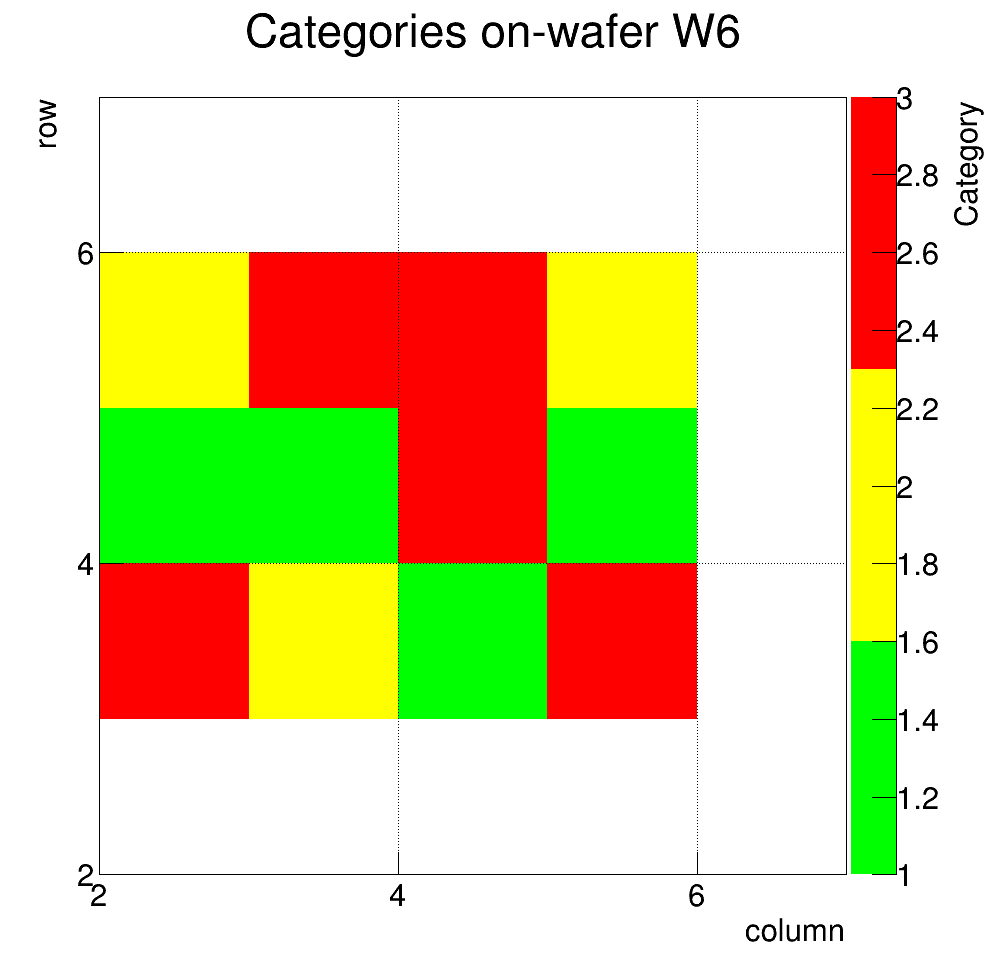

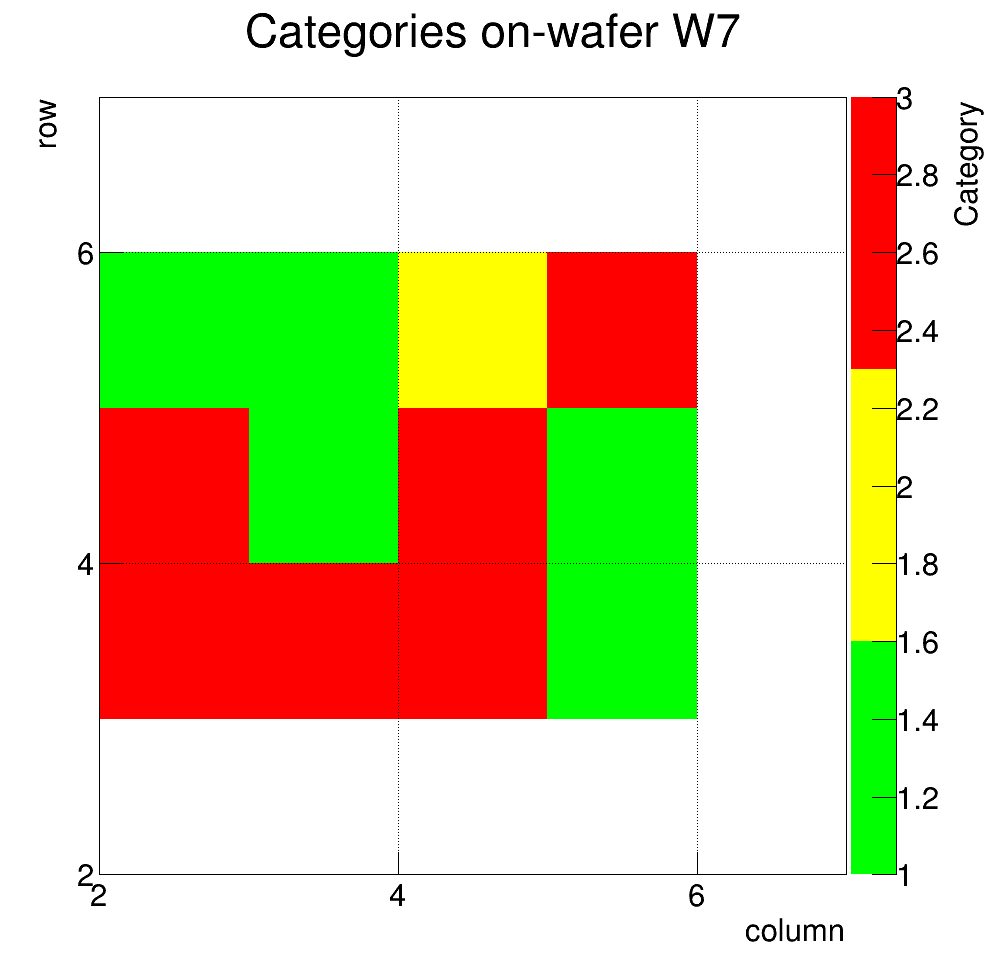

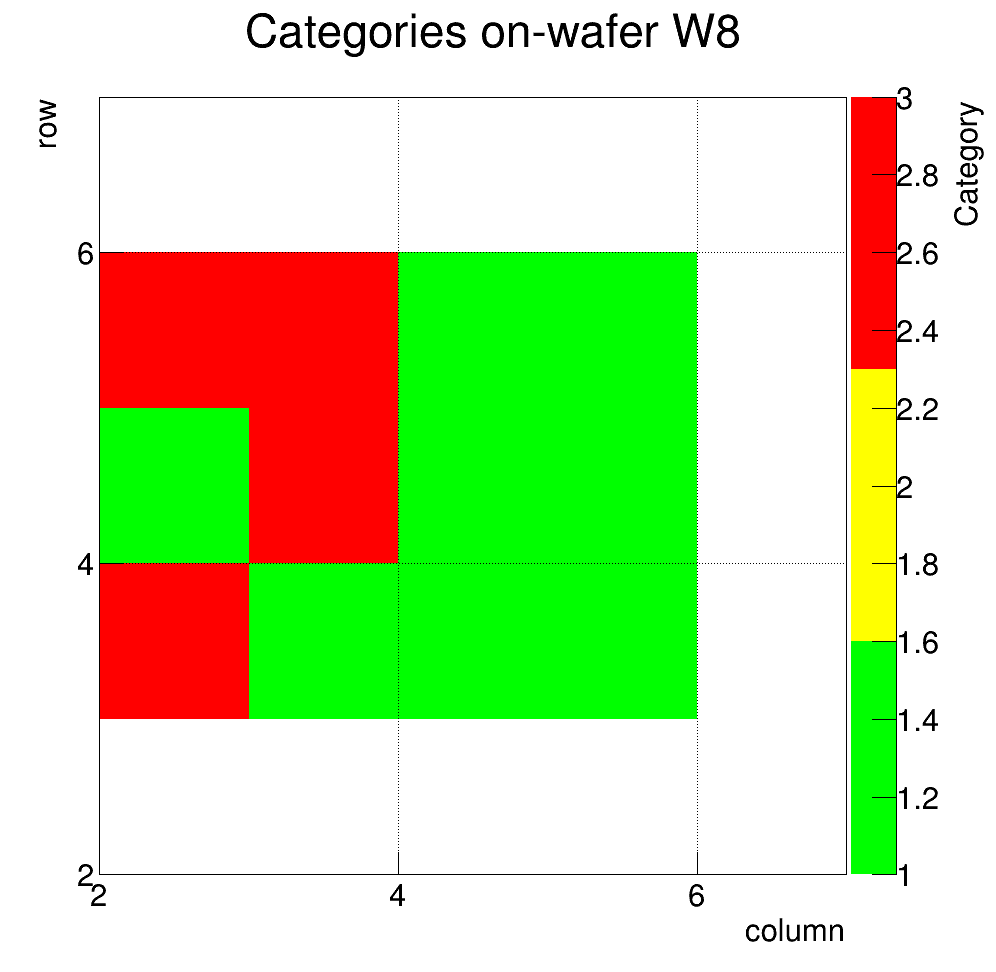

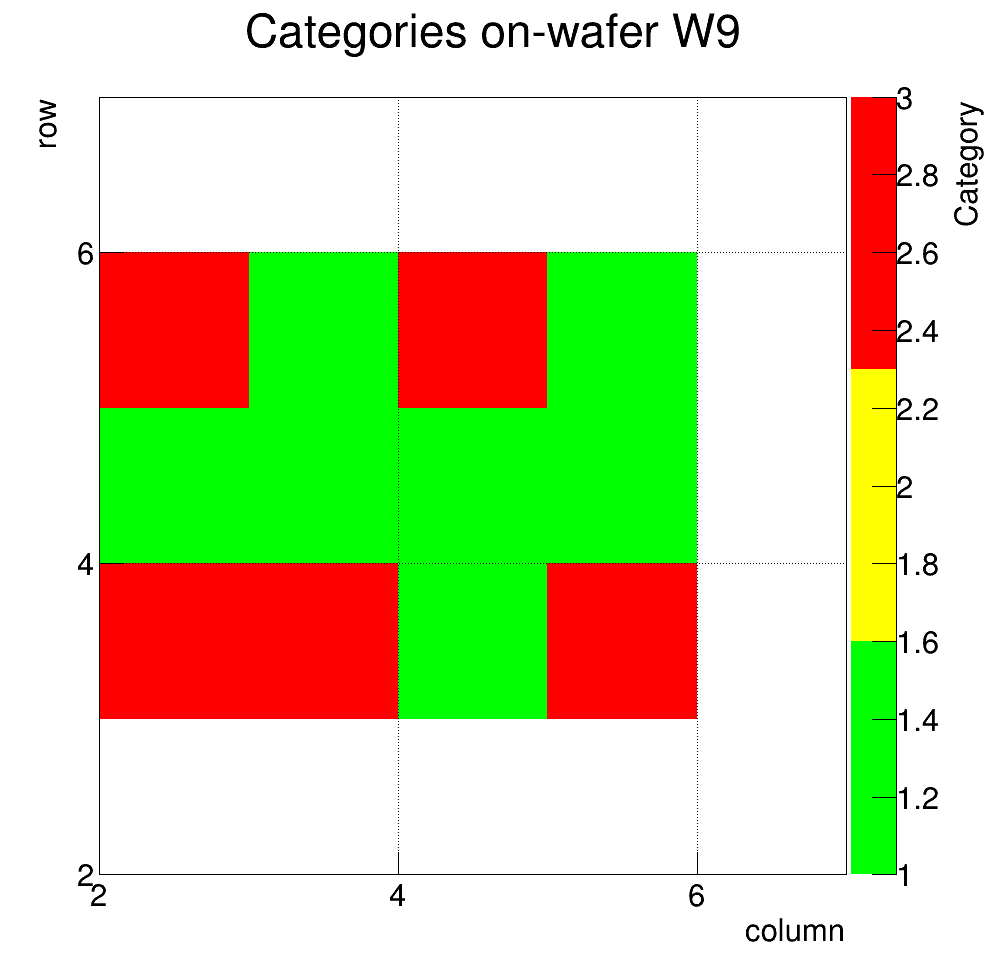

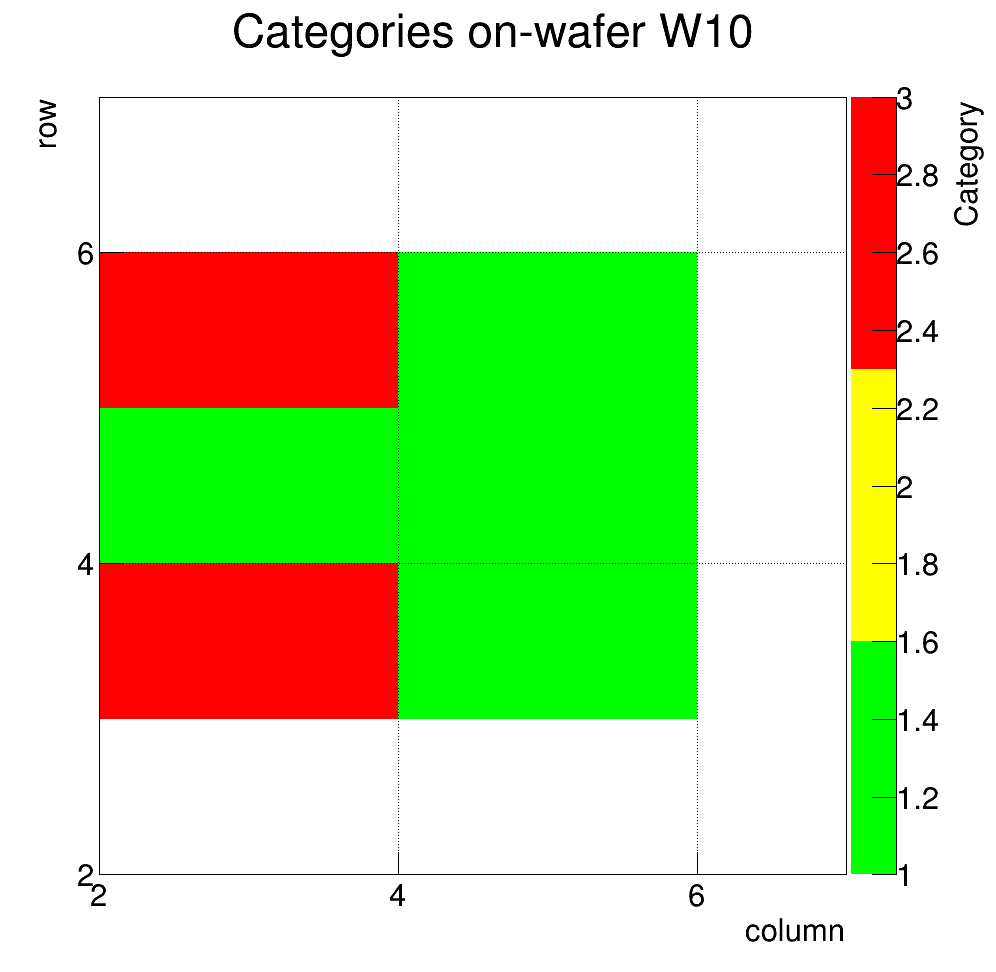

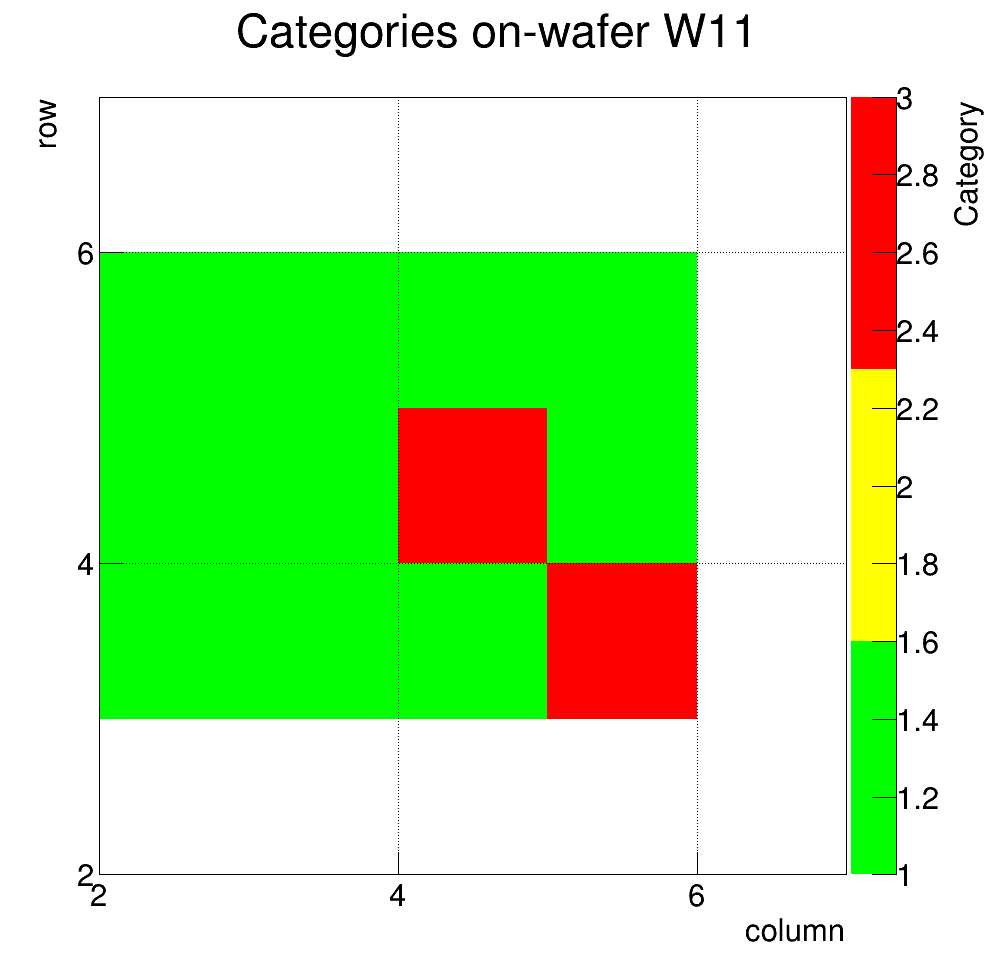

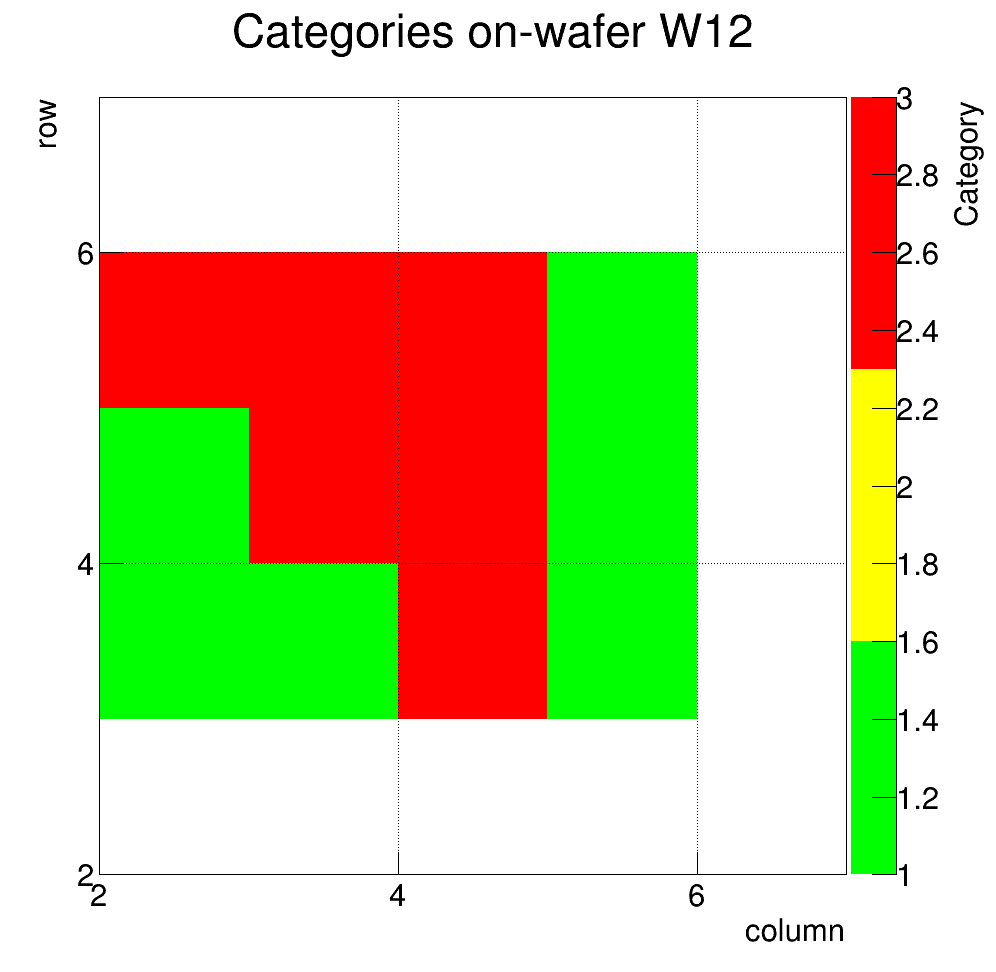

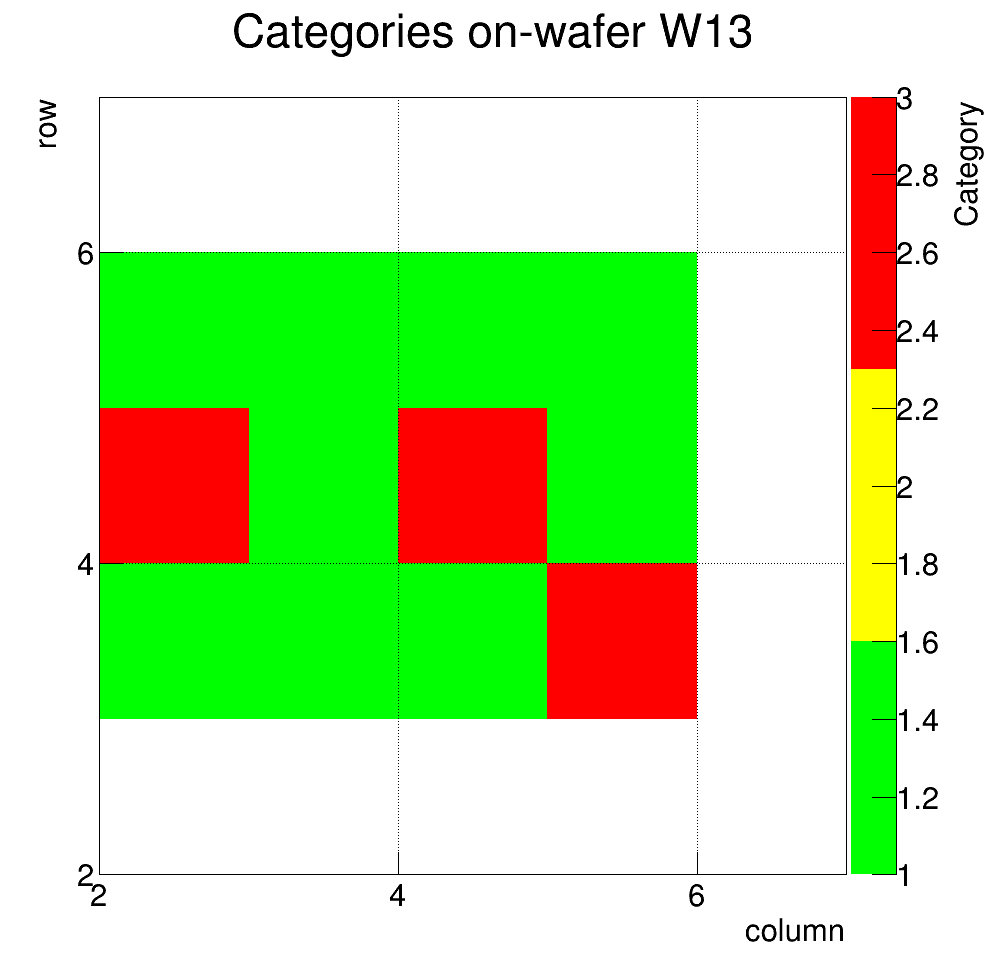

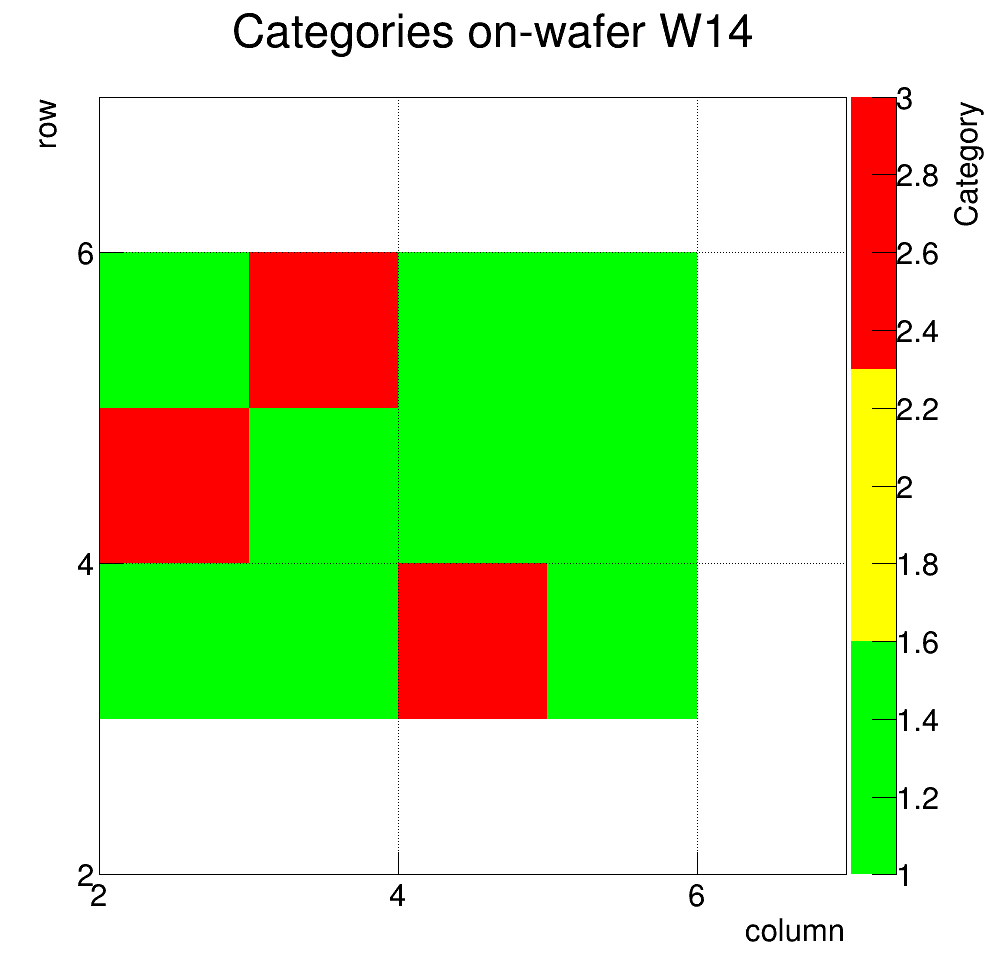

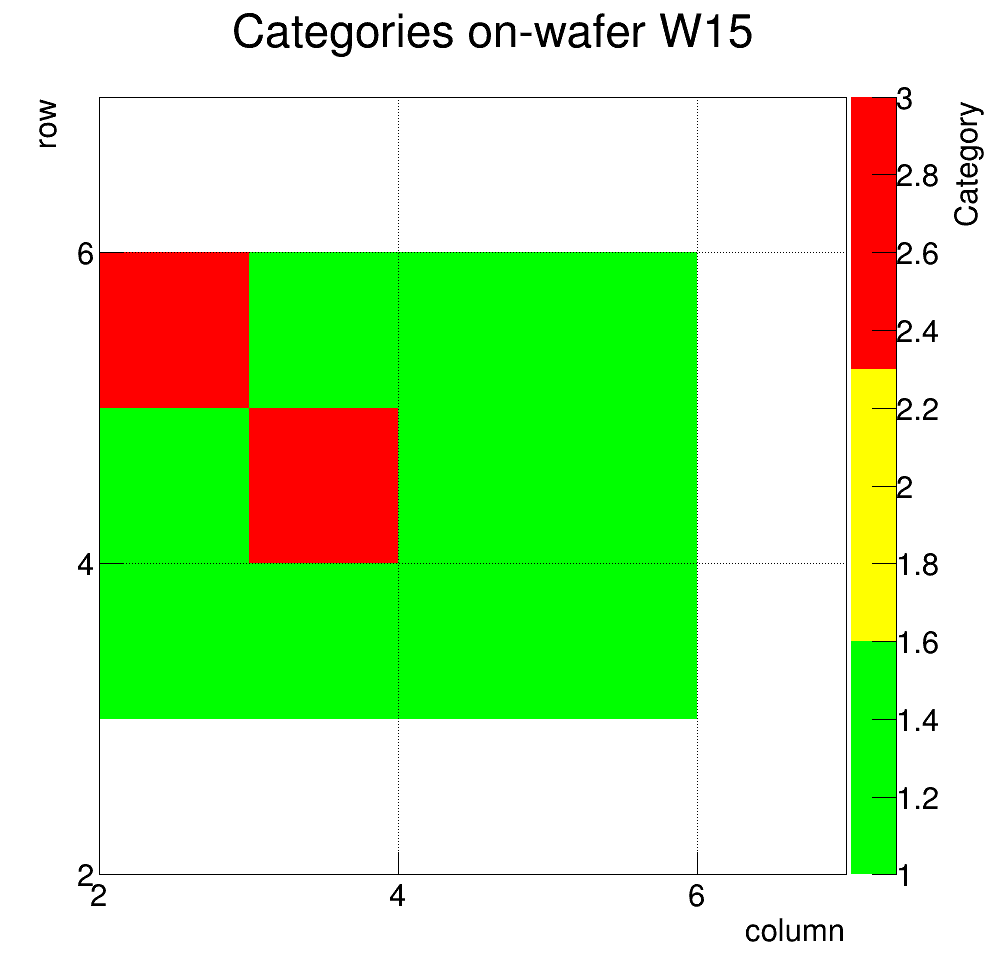

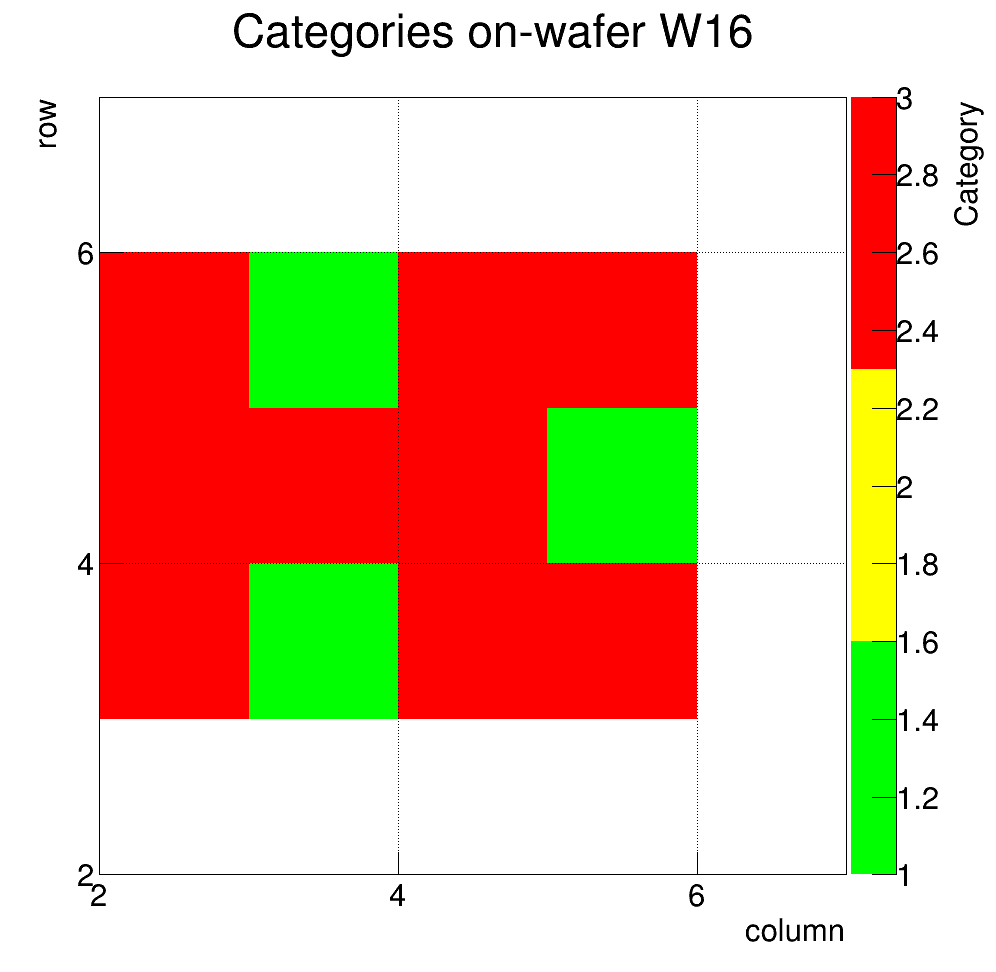

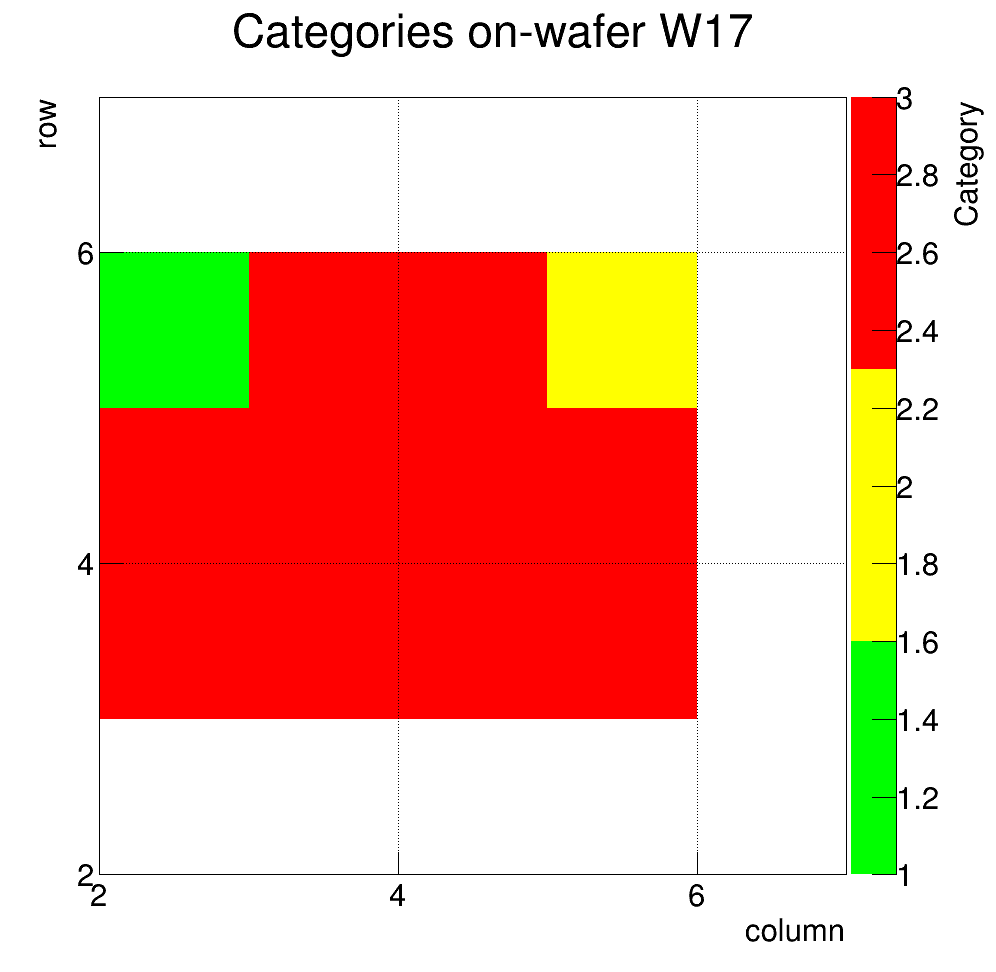

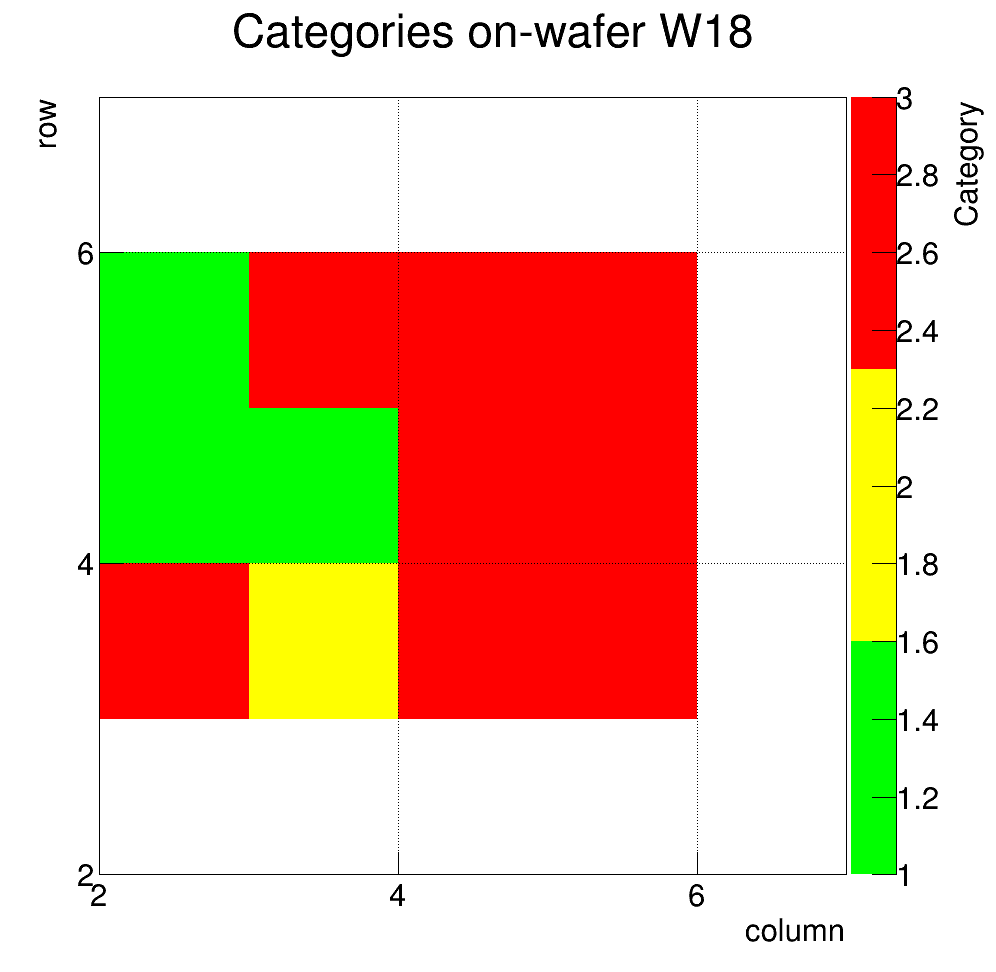

In [5]:
cI_100V = []
cV = []
cbump = []
cnoisy = []

for i in range(18):
  if(bcurrent):
    cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
  if(bvoltage):
    cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
  if(bcategory):
    cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
  if(bnoisy):
    cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))


for i in range(18):
 #if( i==14 ):
 if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

  
    #hV_qa[i]->GetZaxis()->SetRangeUser( hV_qa[i]->GetMinimum(), hV_qa[i]->GetMaximum() ); //Alternative colored axis range
    hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
    hV_qa[i].GetZaxis().SetTitle("[V]")
    hV_qa[i].GetXaxis().SetTitle("column") 
    hV_qa[i].GetYaxis().SetTitle("row")
    hV_qa[i].SetMarkerSize(3.)

    hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
    hbump_qa[i].GetZaxis().SetTitle("Category")
    hbump_qa[i].GetXaxis().SetTitle("column")
    hbump_qa[i].GetYaxis().SetTitle("row")

    hnoisy_qa[i].GetZaxis().SetRangeUser( -0.1, 1 )
    hnoisy_qa[i].GetZaxis().SetTitle("Presence of bad pad(s)")
    hnoisy_qa[i].GetXaxis().SetTitle("column")
    hnoisy_qa[i].GetYaxis().SetTitle("row")


    if(bcurrent):
      #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
      cI_100V[i].SetRightMargin(0.15)
      cI_100V[i].cd()
      hI_qa_100V[i].Draw("textcolz")
      root.gPad.SetGrid(1,1)
      root.gPad.SetLogz(1)
      root.gPad.Update()
      cI_100V[i].Update()
      hI_qa_100V[i].GetXaxis().SetNdivisions(4)
      hI_qa_100V[i].GetYaxis().SetNdivisions(3)
  
      if(save):
        #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
        cI_100V[i].SaveAs(save_path+"I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")


    if(bvoltage):
      root.gStyle.SetPaintTextFormat("1.1f")
      #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
      cV[i].SetRightMargin(0.15)
      cV[i].cd()
      hV_qa[i].Draw("textcolz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cV[i].Update()
      hV_qa[i].GetXaxis().SetNdivisions(4)
      hV_qa[i].GetYaxis().SetNdivisions(3)
  
      if(save): 
        #cV[i].SaveAs( "pics/VBD_W"+str(i+1)+"_FINAL_py.png",i+1)
        cV[i].SaveAs(save_path+"VBD_W"+str(i+1)+"_FINAL_py.png")


    if(bcategory):
      #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
      cbump[i].SetRightMargin(0.15)
      cbump[i].cd()
      hbump_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cbump[i].Update()
      hbump_qa[i].GetXaxis().SetNdivisions(4)
      hbump_qa[i].GetYaxis().SetNdivisions(3)
       
      if(save):
        #cbump[i].SaveAs("pics/categories_W"+str(i+1)+"_FINAL_py.png" )
        cbump[i].SaveAs(save_path+"categories_W"+str(i+1)+"_FINAL_py.png" )   


    if(bnoisy):
      #cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))
      cnoisy[i].SetRightMargin(0.15)
      cnoisy[i].cd()
      hnoisy_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cnoisy[i].Update()
      hnoisy_qa[i].GetXaxis().SetNdivisions(4)
      hnoisy_qa[i].GetYaxis().SetNdivisions(3)
       
      if(save):
        cnoisy[i].SaveAs("pics/noisy_W"+str(i+1)+"_FINAL_py.png")